# Lazypredict

In [1]:
from lazypredict.Supervised import LazyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd

In [2]:
df = pd.read_excel("../Data Final/Final_PM14.xlsx")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Start_Time               906 non-null    datetime64[us]
 1   End_Time                 906 non-null    datetime64[us]
 2   Data_Count               906 non-null    int64         
 3   Mean_Creping             906 non-null    float64       
 4   Mean_Yankee Speed        906 non-null    float64       
 5   Mean_Pope Reel Speed     906 non-null    float64       
 6   Mean_Yankee Pressure     906 non-null    float64       
 7   Mean_Stock Flow          906 non-null    float64       
 8   Mean_Stock Consistency   906 non-null    float64       
 9   Mean_Flow Coating        906 non-null    float64       
 10  Mean_Flow Release        906 non-null    float64       
 11  Mean_Jet Wire Ratio      906 non-null    float64       
 12  Mean_Load KWH Refiner    906 non-null    float6

In [4]:
# Cleaning
df['MDWT'] = pd.to_numeric(df['MDWT'], errors='coerce')
df = df.dropna()

# Cleaning - GSM
df['GSM'] = df['GSM'].astype(str)
df = df[df['GSM'].str.len() <= 4].copy()
df['GSM'] = df['GSM'].str.replace(',', '.')
df['GSM'] = df['GSM'].astype(float)

# Create Pseudo_Mass Feature
df['pseudo_mass'] = (df['Mean_Stock Flow'] * df['Mean_Stock Consistency'])/ df['Mean_Yankee Speed']

# Create Coating-Release Ratio Feature
df['coating_release_ratio'] = df['Mean_Flow Coating'] / df['Mean_Flow Release']


Feature Terpilih:
['Mean_Yankee Speed', 'Mean_Pope Reel Speed', 'Mean_Yankee Pressure', 'Mean_Creping', '% NBKP', 'Mean_Load KWH Refiner', 'Mean_Jet Wire Ratio', 'GSM', 'coating_release_ratio', 'pseudo_mass', 'Mean_Coating/(Area.Min)']

Jumlah Feature Optimal:
11

Ranking Feature:
                    Feature  Ranking  Selected
0         Mean_Yankee Speed        1      True
1      Mean_Pope Reel Speed        1      True
2      Mean_Yankee Pressure        1      True
3              Mean_Creping        1      True
4                    % NBKP        1      True
5     Mean_Load KWH Refiner        1      True
6       Mean_Jet Wire Ratio        1      True
7                       GSM        1      True
8     coating_release_ratio        1      True
9               pseudo_mass        1      True
10  Mean_Coating/(Area.Min)        1      True


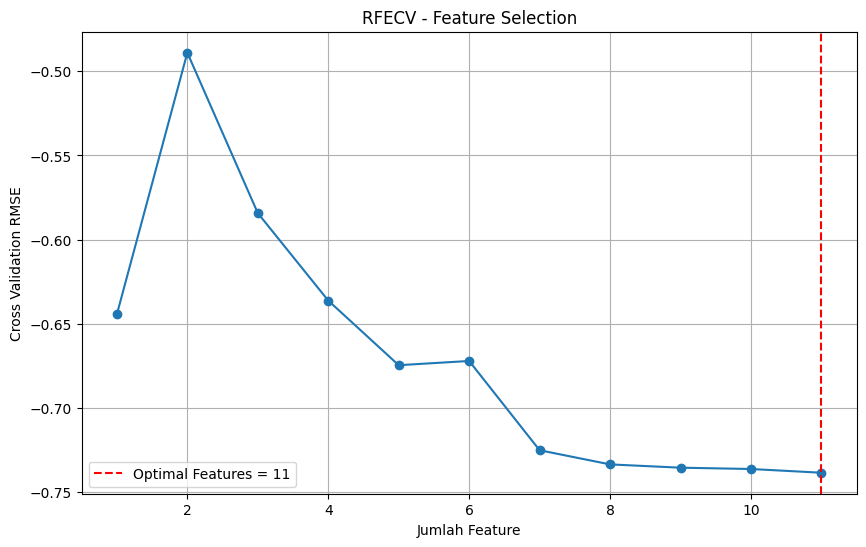

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import RFECV
from sklearn.model_selection import KFold

# =========================================
# FEATURES
# =========================================

features = [
    'Mean_Yankee Speed',
    'Mean_Pope Reel Speed',
    'Mean_Yankee Pressure',
    'Mean_Creping',
    '% NBKP',
    'Mean_Load KWH Refiner',
    'Mean_Jet Wire Ratio',
    'GSM',
    'coating_release_ratio',
    'pseudo_mass',
    'Mean_Coating/(Area.Min)'
]

# =========================================
# X DAN y
# =========================================


X = df[features]
y = df['MDT']   # ganti dengan nama target Anda

# =========================================
# MODEL
# =========================================

model = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# =========================================
# CROSS VALIDATION
# =========================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================
# RFECV
# =========================================

selector = RFECV(
    estimator=model,
    step=1,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)

selector.fit(X, y)

# =========================================
# HASIL FEATURE TERPILIH
# =========================================

selected_features = X.columns[selector.support_]

print("Feature Terpilih:")
print(selected_features.tolist())

print("\nJumlah Feature Optimal:")
print(selector.n_features_)

# =========================================
# RANKING FEATURE
# =========================================

ranking = pd.DataFrame({
    'Feature': X.columns,
    'Ranking': selector.ranking_,
    'Selected': selector.support_
}).sort_values(by='Ranking')

print("\nRanking Feature:")
print(ranking)

# =========================================
# VISUALISASI RFECV
# =========================================

mean_scores = selector.cv_results_['mean_test_score']

# karena scoring negatif RMSE
rmse_scores = -mean_scores

plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(rmse_scores)+1),
    rmse_scores,
    marker='o'
)

plt.axvline(
    selector.n_features_,
    color='red',
    linestyle='--',
    label=f'Optimal Features = {selector.n_features_}'
)

plt.xlabel('Jumlah Feature')
plt.ylabel('Cross Validation RMSE')
plt.title('RFECV - Feature Selection')
plt.grid(True)
plt.legend()

plt.show()